[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aubreycoffey/single-cell-analysis-pipeline/blob/main/notebooks/03_differential_expression.ipynb)

# Notebook 3: Differential Expression

This notebook identifies marker genes for each cell type using the Wilcoxon rank-sum test, then visualizes the results.

## Google Drive setup

Mount Drive to persist data between notebook sessions. All `.h5ad` files will be saved to `MyDrive/scrnaseq-pbmc-pipeline-data/`.

In [6]:
from google.colab import drive
drive.mount('/content/drive')
import os
DATA_DIR = '/content/drive/MyDrive/scrnaseq-pbmc-pipeline-data'
os.makedirs(DATA_DIR, exist_ok=True)
print(f'Data directory: {DATA_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data directory: /content/drive/MyDrive/scrnaseq-pbmc-pipeline-data


In [7]:
import sys
!{sys.executable} -m pip install -q scanpy leidenalg python-igraph

In [8]:
import scanpy as sc
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor='white')

/tmp/ipykernel_3137/1465342122.py:3: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor='white')


In [9]:
adata = sc.read_h5ad(f'{DATA_DIR}/pbmc_clustered.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 2638 × 1830
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'cell_type'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'


## 1. Rank genes per cluster

We use the Wilcoxon rank-sum test to find genes that are significantly upregulated in each cell type compared to all others. We run this on the raw (log-normalized) counts stored in `adata.raw`.

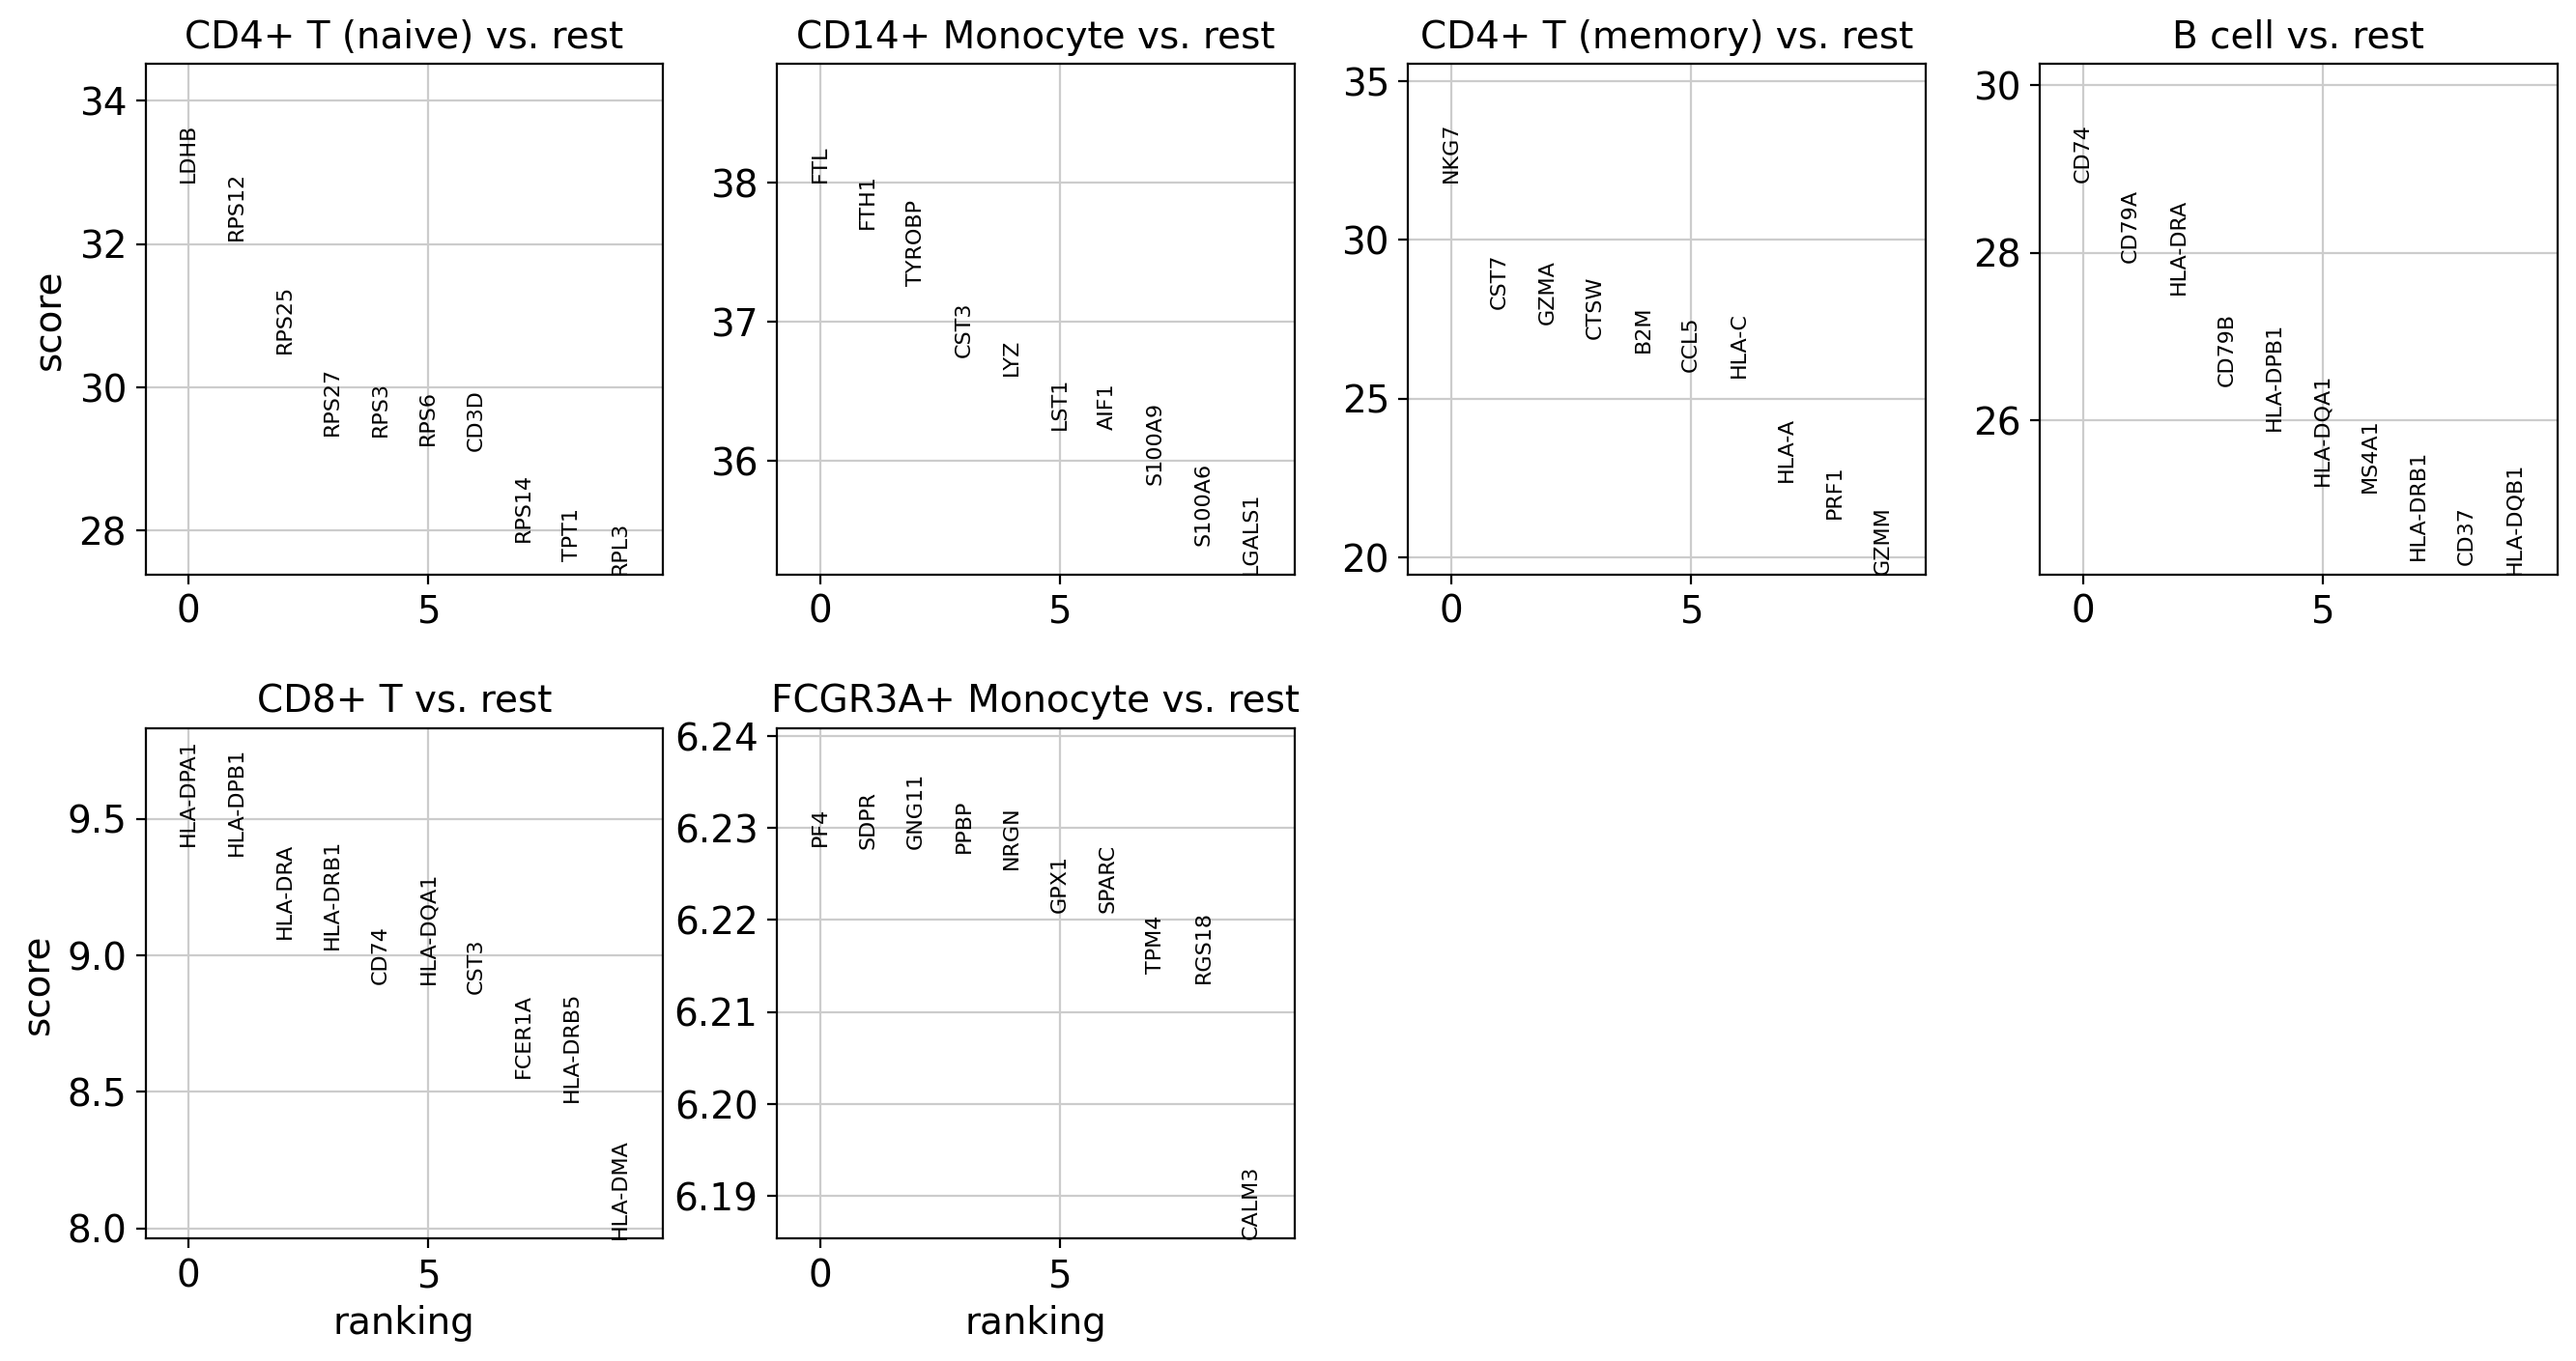

In [10]:
sc.tl.rank_genes_groups(adata, groupby='cell_type', method='wilcoxon', use_raw=True)
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

## 2. Visualize top markers

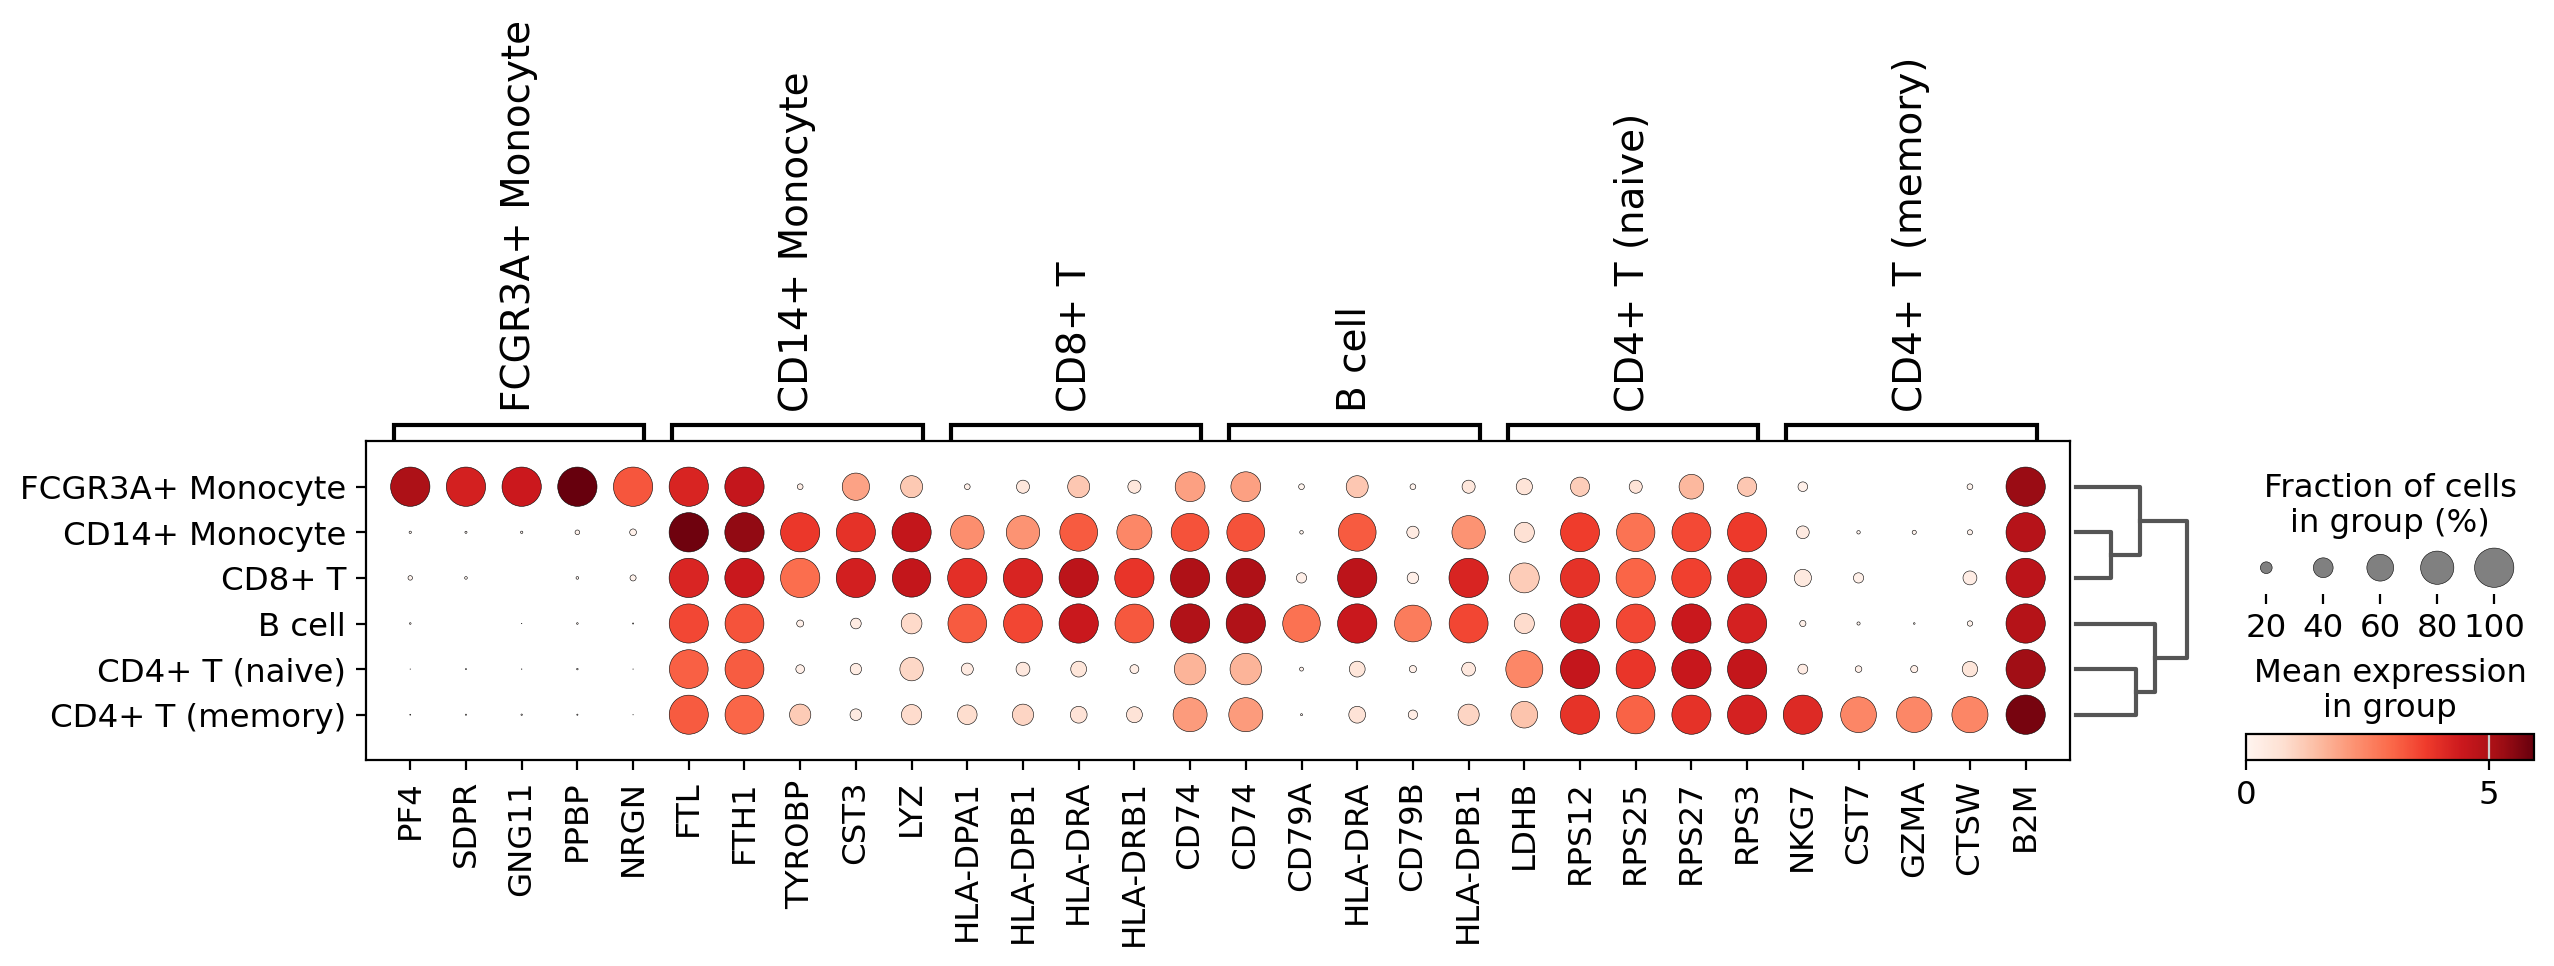

In [11]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, groupby='cell_type')

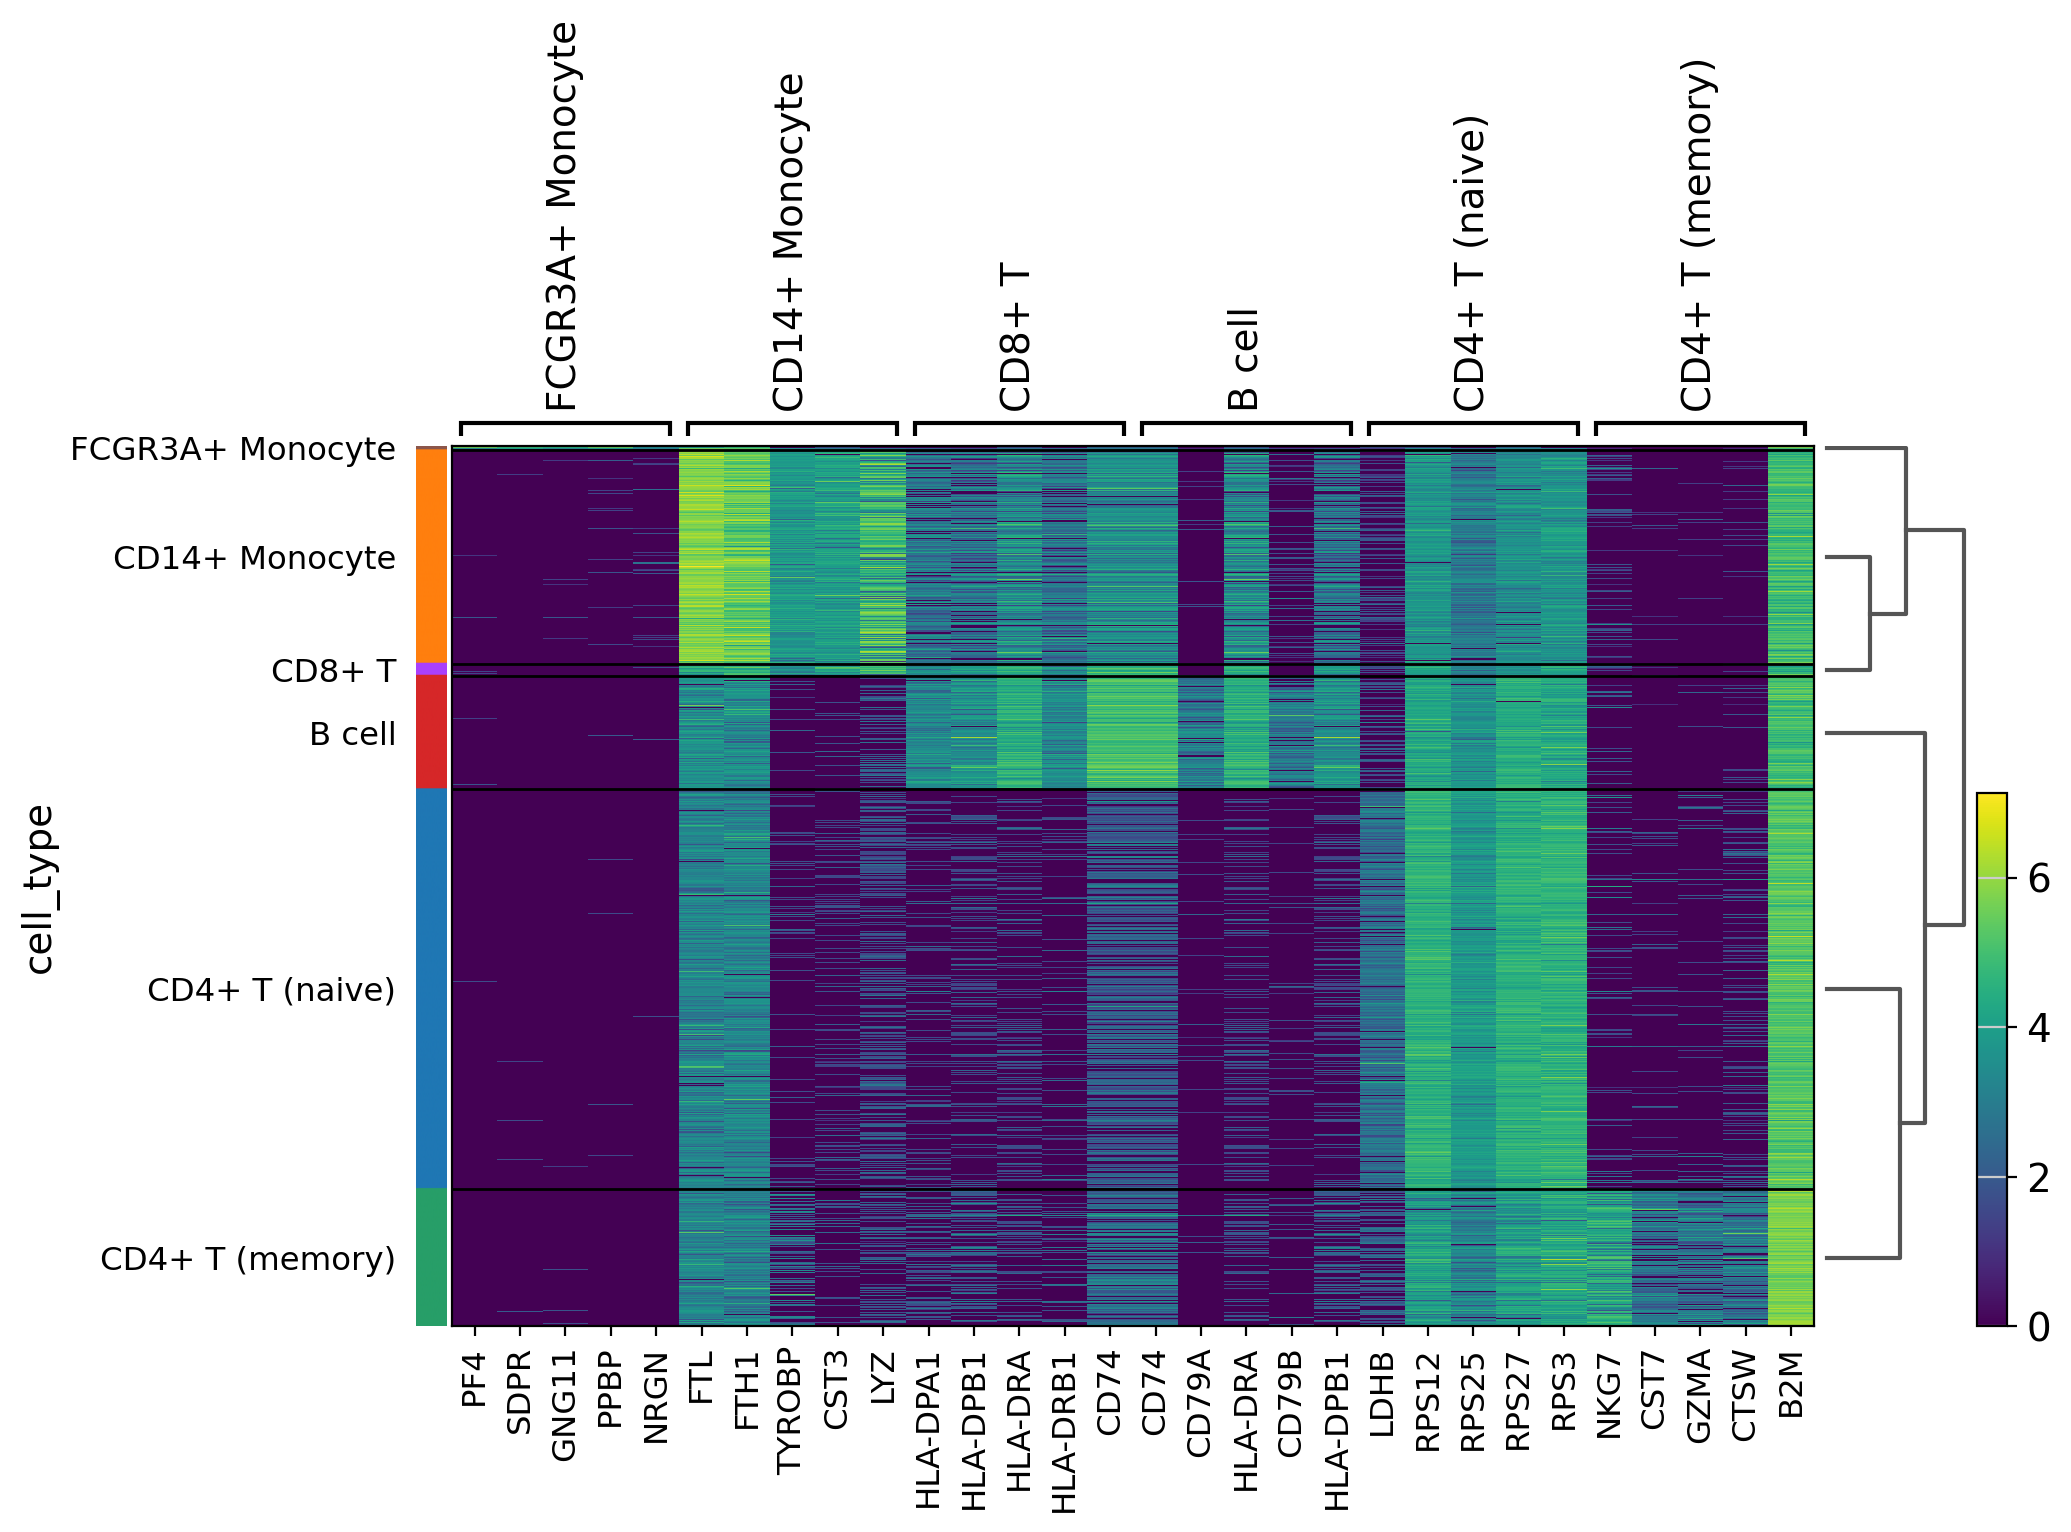

In [12]:
sc.pl.rank_genes_groups_heatmap(adata, n_genes=5, groupby='cell_type',
                                   show_gene_labels=True)

## 3. Inspect a specific cluster

Let's look at the top DE genes for CD8+ T cells and verify they make biological sense.

       names    scores  logfoldchanges         pvals     pvals_adj
0   HLA-DPA1  9.400325        4.278314  5.439477e-21  5.201015e-17
1   HLA-DPB1  9.364963        4.434845  7.607716e-21  5.201015e-17
2    HLA-DRA  9.059811        4.608550  1.306768e-19  5.955813e-16
3   HLA-DRB1  9.020483        4.237392  1.872622e-19  6.401090e-16
4       CD74  8.894346        3.639147  5.876431e-19  1.340470e-15
5   HLA-DQA1  8.894236        4.825887  5.882263e-19  1.340470e-15
6       CST3  8.859975        4.912794  8.003226e-19  1.563259e-15
7     FCER1A  8.552179        8.774558  1.207857e-17  2.064378e-14
8   HLA-DRB5  8.462948        3.888589  2.607032e-17  3.960660e-14
9    HLA-DMA  7.962036        3.505623  1.692312e-15  2.313899e-12
10  HLA-DQB1  7.933834        4.084098  2.124817e-15  2.641147e-12
11  HLA-DQA2  7.311964        4.175992  2.632662e-13  2.999699e-10
12      LSP1  7.217444        2.206801  5.297388e-13  5.173656e-10
13       LYZ  7.185717        4.257752  6.685548e-13  6.094100

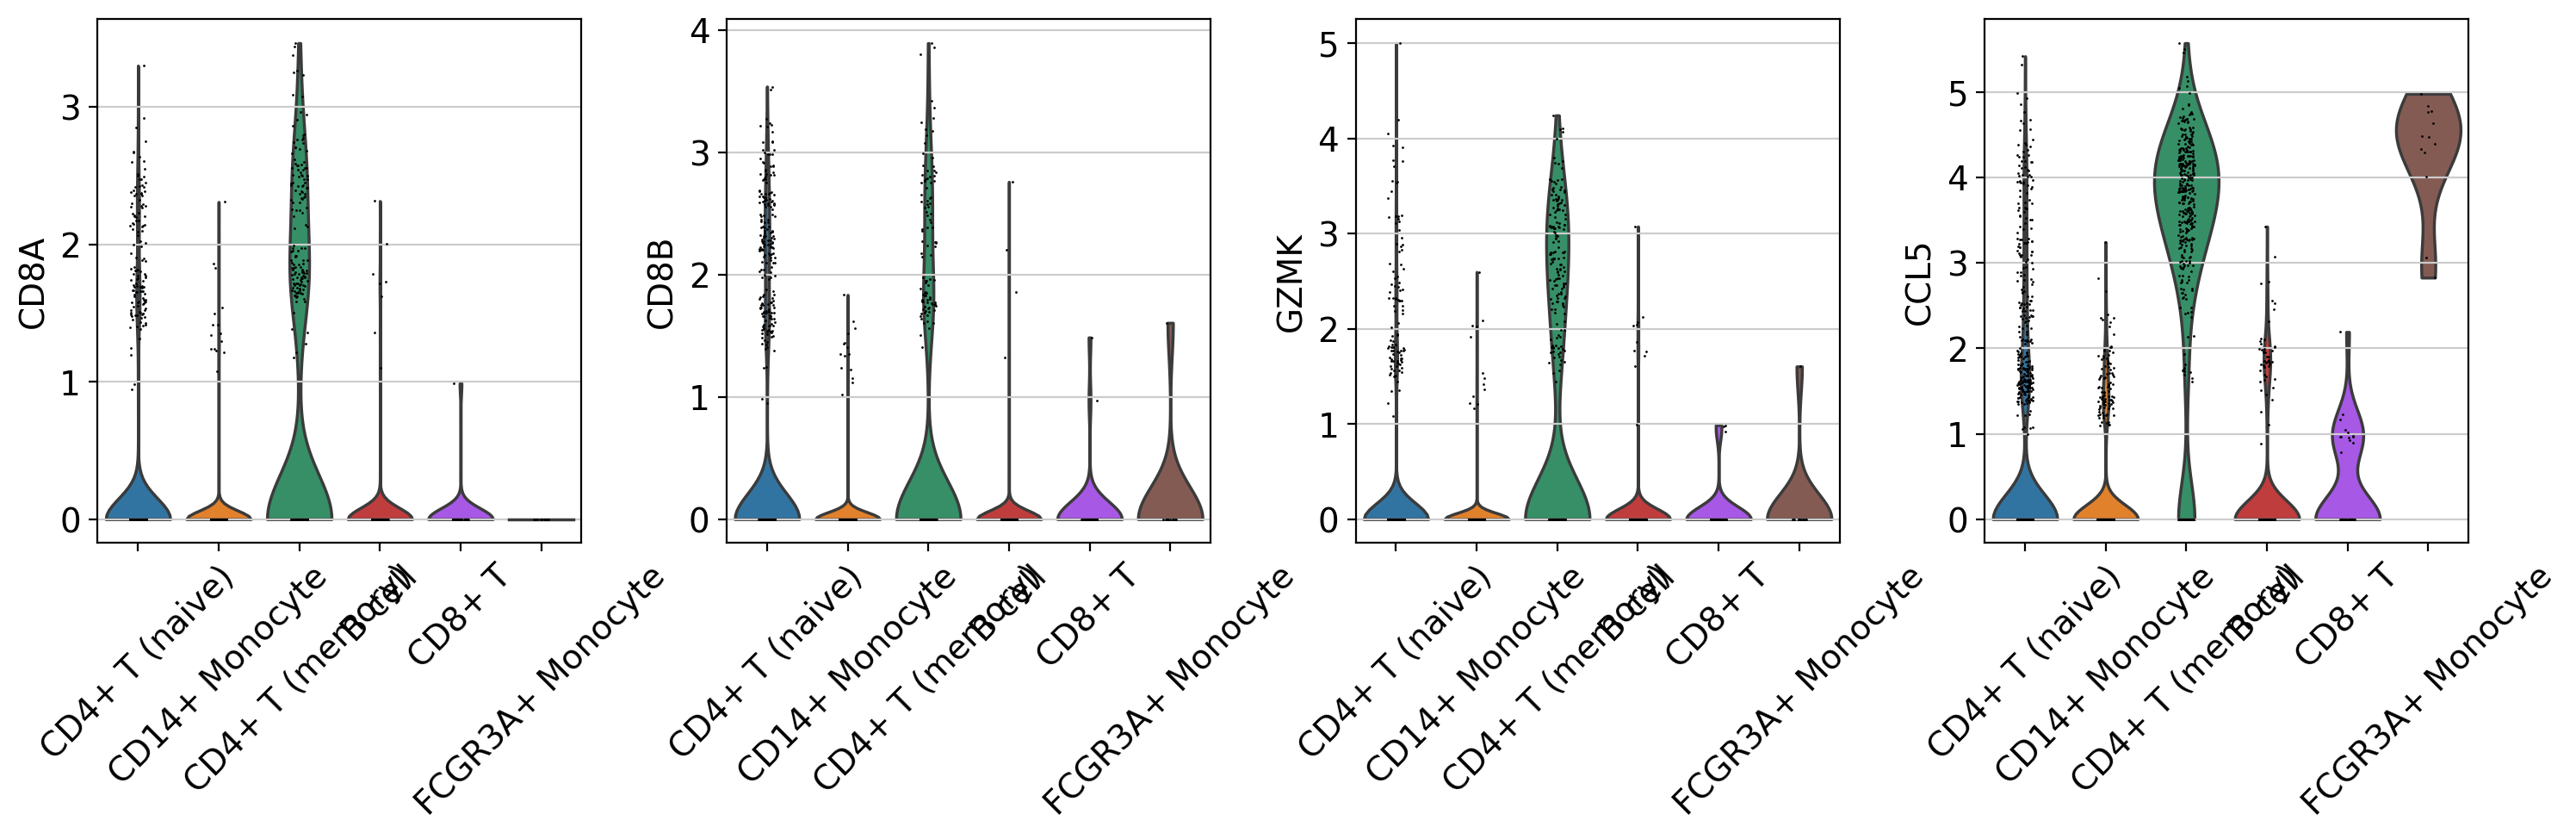

In [13]:
import pandas as pd

de_results = sc.get.rank_genes_groups_df(adata, group='CD8+ T')
print(de_results.head(15).to_string())

# Visualize top hits
sc.pl.violin(adata, ['CD8A', 'CD8B', 'GZMK', 'CCL5'], groupby='cell_type', rotation=45)

## 4. Save

In [14]:
adata.write(f'{DATA_DIR}/pbmc_de.h5ad')
print('Saved to ../data/pbmc_de.h5ad')

Saved to ../data/pbmc_de.h5ad
